# Modelling: Classical

This notebook splits `data/processed/cleaned.csv` into training, validation, and test sets, builds a single pipeline that combines text vectorisation, categorical encoding, and a classifier, and tunes that pipeline with cross-validation. Two classical model variants, Logistic Regression and Linear SVM, are tuned and compared on the validation set.

The test set is not touched in this notebook. Final model selection and the one-time test-set evaluation happen in `06_evaluation.ipynb`, alongside the LSTM comparison from `05_modelling_lstm.ipynb`.

In [ ]:
# Standard library
import sys

# Third-party
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import LinearSVC

# Show every column when previewing a DataFrame, rather than truncating with "..."
pd.set_option("display.max_columns", None)

# Make the repository root importable so src/ can be reached from notebooks/
sys.path.append("..")

# A fixed seed used for every split and every stochastic model, so results are reproducible
# and so 05_modelling_lstm.ipynb can recreate the exact same split by reusing this value.
RANDOM_STATE = 42

## Load the Cleaned Dataset

The dataset produced by `02_data_preparation.ipynb` is loaded and its shape is checked to confirm it still matches the 11 columns and 17,880 rows saved there.

In [2]:
# Load the cleaned dataset and report its shape
df = pd.read_csv("../data/processed/cleaned.csv")
print(df.shape)

(17880, 11)


## Split into Train, Validation, and Test

The data is split before anything is fitted: no vectoriser, encoder, or model ever sees validation or test rows during fitting. `01_data_understanding.ipynb` found that only 4.84% of postings are fraudulent, so `stratify` is used on both splits to keep that same proportion in every set.

Two calls to `train_test_split` produce the three sets:
1. the first separates 70% of the rows for training and holds out the remaining 30%
2. the second splits that 30% down the middle into a 15% validation set and a 15% test set.

`RANDOM_STATE` is fixed so that `05_modelling_lstm.ipynb` can repeat the exact same two calls, with the exact same value, and see the exact same three sets without either notebook having to save split files.

The class balance of each resulting set is printed to confirm stratification held.

In [3]:
# Separate the features from the label
X = df.drop(columns=["fraudulent"])
y = df["fraudulent"]

# First split: 70% train, 30% held out for validation and test combined
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# Second split: the 30% holdout is split evenly into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.50, stratify=y_holdout, random_state=RANDOM_STATE
)

# Report the size and class balance of each split
for name, split_y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    fraud_rate = split_y.mean() * 100
    print(f"{name}: {len(split_y)} rows, {fraud_rate:.2f}% fraudulent")

Train: 12516 rows, 4.84% fraudulent
Validation: 2682 rows, 4.85% fraudulent
Test: 2682 rows, 4.85% fraudulent


## Build the Preprocessing Pipeline

`X` has three kinds of columns that each need different treatment: `text` needs to become a numeric feature, the six metadata columns are categories, and the three binary flags are already usable as-is.

A `ColumnTransformer` applies a `TfidfVectorizer` to `text` and a `OneHotEncoder` is applied to the metadata columns. The three binary flags remain unchanged. The encoder is configured with `handle_unknown="ignore"` because a metadata value that never appears in the training set can still appear in the validation or test set. Without this parameter, the encoder will raise an error instead of encoding that row as all-zeros for that column.

This `ColumnTransformer` is reused, unfitted, inside each model's own `Pipeline` below, so it is refitted on the training fold every time cross-validation runs. It never sees validation or test rows during fitting.

In [4]:
# The six metadata columns to one-hot encode: telecommuting, has_company_logo, and has_questions are the only columns left over which remain unchanged
metadata_fields = ["department", "employment_type", "required_experience", "required_education", "industry", "function"]


def build_preprocessor():
    """Return a fresh, unfitted ColumnTransformer for the text and metadata columns.

    A new instance is built for each pipeline below so the two models never share
    transformer state, even though each is refitted independently during tuning.
    """
    return ColumnTransformer(
        transformers=[
            ("text", TfidfVectorizer(), "text"),
            ("categorical", OneHotEncoder(handle_unknown="ignore"), metadata_fields),
        ],
        remainder="passthrough",
    )

## Fit and Tune Logistic Regression

The preprocessor from above and `LogisticRegression` are combined into one `Pipeline`. `class_weight="balanced"` is set because only 4.84% of postings are fraudulent. Without this parameter, the model can reach high accuracy by predicting "legitimate" almost every time, while missing most of the fraudulent postings the project cares about detecting.

`GridSearchCV` tunes three hyperparameters together: the maximum vocabulary size and n-gram range used by `TfidfVectorizer`, and the regularisation strength `C` used by `LogisticRegression`.

Cross-validation is stratified five-fold, and every fold refits the whole pipeline (preprocessor included) on that fold's training rows only. This ensures nothing here is fitted on data it will later be scored on. Five folds are used rather than three because the training set is large enough (12,516 rows) that the extra refits stay cheap, while giving each fold more of the roughly 606 fraudulent training rows to fit on and a steadier per-fold F1 estimate for that minority class.

The scoring metric used is F1 on the fraudulent class, which balances precision and recall instead of rewarding the majority-class shortcut that plain accuracy will.

In [5]:
# Build the Logistic Regression pipeline
logistic_regression_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])

# Tune the TF-IDF vocabulary size, n-gram range, and regularisation strength together
logistic_regression_param_grid = {
    "preprocessor__text__max_features": [3000, 5000],
    "preprocessor__text__ngram_range": [(1, 1), (1, 2)],
    "classifier__C": [0.1, 1, 10],
}

# Fit the grid search on the training set only, scoring by F1 on the fraudulent class
logistic_regression_search = GridSearchCV(logistic_regression_pipeline, logistic_regression_param_grid, scoring="f1", cv=5, n_jobs=-1)
logistic_regression_search.fit(X_train, y_train)

print("Best parameters:", logistic_regression_search.best_params_)
print(f"Best cross-validated F1: {logistic_regression_search.best_score_:.4f}")

Best parameters: {'classifier__C': 10, 'preprocessor__text__max_features': 5000, 'preprocessor__text__ngram_range': (1, 1)}
Best cross-validated F1: 0.7668


## Fit and Tune Linear SVM

The same preprocessor and tuning approach are used for `LinearSVC` to ensure that the two variants are compared on equally. `LinearSVC` has no `predict_proba`, and it only produces a decision-function margin, not a calibrated probability.

Turning this margin into a probability (for example with `CalibratedClassifierCV`) is deferred to `06_evaluation.ipynb`, and only if this variant turns out to win.

This notebook only needs to compare the two variants, not decide how either would ship.

In [6]:
# Build the Linear SVM pipeline
svm_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", LinearSVC(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)),
])

# Tune the same TF-IDF settings, alongside the SVM's own regularisation strength
svm_param_grid = {
    "preprocessor__text__max_features": [3000, 5000],
    "preprocessor__text__ngram_range": [(1, 1), (1, 2)],
    "classifier__C": [0.1, 1, 10],
}

# Fit the grid search on the training set only, scoring by F1 on the fraudulent class
svm_search = GridSearchCV(svm_pipeline, svm_param_grid, scoring="f1", cv=5, n_jobs=-1)
svm_search.fit(X_train, y_train)

print("Best parameters:", svm_search.best_params_)
print(f"Best cross-validated F1: {svm_search.best_score_:.4f}")

Best parameters: {'classifier__C': 10, 'preprocessor__text__max_features': 5000, 'preprocessor__text__ngram_range': (1, 1)}
Best cross-validated F1: 0.7993


## Compare on the Validation Set

Each tuned pipeline is used only to predict on the validation set from here on, and neither pipeline is refitted.

The classification report shows precision, recall, and F1 for both classes, which matters here because accuracy alone will look high for a model that just predicts "legitimate" most of the time.

`LogisticRegression` provides `predict_proba`, and `LinearSVC` provides `decision_function`. Both are valid inputs to `roc_auc_score`, since it only needs scores that rank postings from least to most likely fraudulent and not calibrated probabilities.

In [7]:
# Logistic Regression: predictions and a ranking score for ROC-AUC
logistic_regression_best = logistic_regression_search.best_estimator_
logistic_regression_predictions = logistic_regression_best.predict(X_val)
logistic_regression_scores = logistic_regression_best.predict_proba(X_val)[:, 1]

print("Logistic Regression\n")
print(classification_report(y_val, logistic_regression_predictions))
print(f"ROC-AUC: {roc_auc_score(y_val, logistic_regression_scores):.4f}")

Logistic Regression

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2552
           1       0.78      0.91      0.84       130

    accuracy                           0.98      2682
   macro avg       0.89      0.95      0.91      2682
weighted avg       0.98      0.98      0.98      2682

ROC-AUC: 0.9944


In [8]:
# Linear SVM: predictions and a ranking score for ROC-AUC
svm_best = svm_search.best_estimator_
svm_predictions = svm_best.predict(X_val)
svm_scores = svm_best.decision_function(X_val)

print("Linear SVM\n")
print(classification_report(y_val, svm_predictions))
print(f"ROC-AUC: {roc_auc_score(y_val, svm_scores):.4f}")

Linear SVM

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2552
           1       0.85      0.85      0.85       130

    accuracy                           0.99      2682
   macro avg       0.92      0.92      0.92      2682
weighted avg       0.99      0.99      0.99      2682

ROC-AUC: 0.9927


The confusion matrices for both variants are plotted side by side which makes it easier to compare how many fraudulent postings each model misses (false negatives) against how many legitimate postings it wrongly flags (false positives).

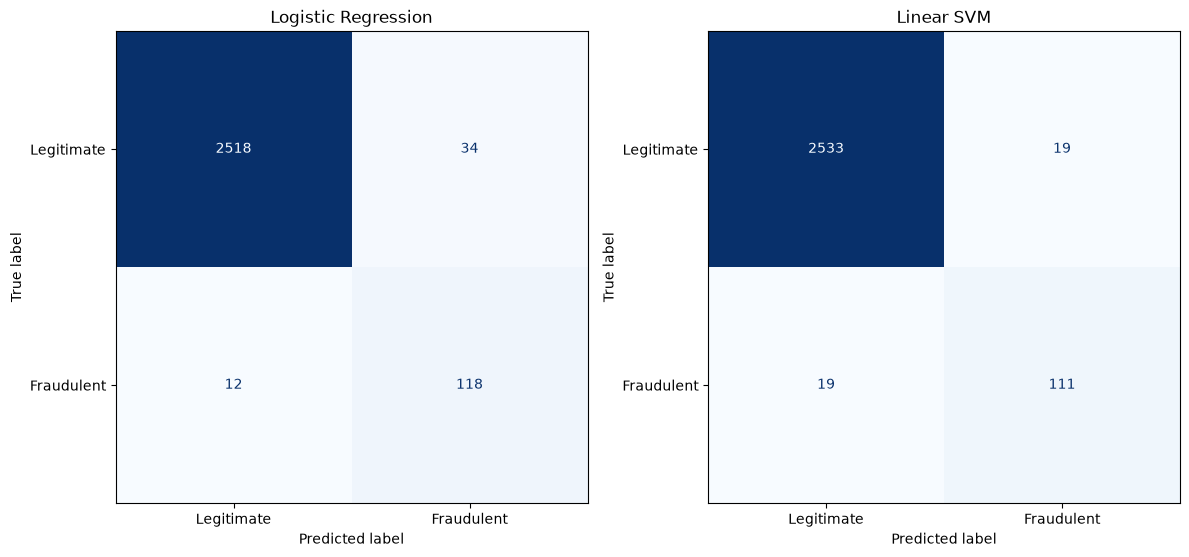

In [9]:
# Plot both confusion matrices side by side for a direct visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

ConfusionMatrixDisplay.from_predictions(y_val, logistic_regression_predictions, display_labels=["Legitimate", "Fraudulent"], ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_val, svm_predictions, display_labels=["Legitimate", "Fraudulent"], ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Linear SVM")

plt.tight_layout()
plt.show()

## Summary

- Split `cleaned.csv` into training (12,516 rows), validation (2,682 rows), and test (2,682 rows) sets. Stratified so each keeps close to the dataset's 4.84% fraud rate (4.84%, 4.85%, and 4.85% respectively). A fixed seed is used so that `05_modelling_lstm.ipynb` can reproduce the same split.
- Built one `ColumnTransformer` (TF-IDF on `text`, one-hot encoding on the six metadata columns, and the three binary flags passed through) shared by both models, and wrapped it with each classifier in its own `Pipeline`.
- Tuned `LogisticRegression` and `LinearSVC`, both with `class_weight="balanced"`, over the same TF-IDF and regularisation-strength grid using five-fold cross-validation on the training set only, scoring by F1 on the fraudulent class. Logistic Regression's best cross-validated F1 was 0.7668 (`C=10`, `max_features=5000`, unigrams only), and Linear SVM's was 0.7993 (`C=10`, `max_features=5000`, unigrams only).
- On the validation set, the Linear SVM has the higher precision (0.85 versus 0.78) and a slightly higher F1 on the fraudulent class (0.85 versus 0.84), while Logistic Regression has the higher recall (0.91 versus 0.85) and the higher ROC-AUC (0.9944 versus 0.9927). Recall matters most for this project, since a missed fraudulent posting is costlier than a false alarm. Hence, the two variants trade off against each other instead of one clearly leading on every metric.
- No model has been chosen yet and the test set remains untouched. `05_modelling_lstm.ipynb` reproduces the same split to train the LSTM comparison model, and `06_evaluation.ipynb` brings both variants and the LSTM together, makes the final selection, and runs the held-out test evaluation once.